In [ ]:
if IN_COLAB:
    !pip install opencv-python pandas numpy tqdm
else:
    print('Local packages already verified')


In [ ]:
# Detect environment (Google Colab vs. Local Environment)
import os
import sys

IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    print("Running in Google Colab environment.")
    DATA_ROOT = "/content/data"
    CODE_ROOT = "/content/Code"
    CHECKPOINT_ROOT = "/content/checkpoints"
    LOGS_ROOT = "/content/logs"
else:
    print("Running in Local Environment (fits system architecture).")
    # Aligns to your local data and scripts directories
    DATA_ROOT = "../data/cnn"
    CODE_ROOT = "../scripts/cnn"
    CHECKPOINT_ROOT = "../scripts/cnn/PhamHungSon_15_CNN_CheckpointsSupRegularized"
    LOGS_ROOT = "../scripts/cnn/LogsSupP2"


Download dataset

In [ ]:
if IN_COLAB:
    !mkdir -p /content/data/raw/train

else:
    print('Local directories already verified in data/cnn/')
if IN_COLAB:
    !mkdir -p /content/data/raw/val

else:
    print('Local directories already verified in data/cnn/')

%cd /content/data/raw

!wget -q http://images.cocodataset.org/zips/val2017.zip

!unzip -q val2017.zip -d val

!rm val2017.zip

print("Done")

/content/data/raw
Done


Split Dataset

In [ ]:
import os
import random
import shutil

random.seed(42)

source_dir = "/content/data/raw/val/val2017"

base_output = "/content/data/split"

train_dir = os.path.join(base_output, "Train")
val_dir = os.path.join(base_output, "Val")
test_dir = os.path.join(base_output, "Test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

images = [
    f for f in os.listdir(source_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images:", len(images))

random.shuffle(images)

train_images = images[:4000]
val_images = images[4000:4800]
test_images = images[4800:5000]

print("Train:", len(train_images))
print("Val:", len(val_images))
print("Test:", len(test_images))

Total images: 5000
Train: 4000
Val: 800
Test: 200


Rename image

In [ ]:
def copy_images(image_list, target_dir):

    for idx, image_name in enumerate(image_list, start=1):

        src = os.path.join(source_dir, image_name)

        dst = os.path.join(target_dir, f"{idx}.jpg")

        shutil.copy(src, dst)

copy_images(train_images, train_dir)
copy_images(val_images, val_dir)
copy_images(test_images, test_dir)

print("Dataset split complete.")

Dataset split complete.


Dataset Synthetic

In [ ]:
import cv2
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

def get_image_files(folder_path):
    return sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

def GetPatches(image, patch_size=128, perturbation=32, border=42, translation=10):

    h, w = image.shape[:2]
    min_size = patch_size + 2 * border + 1

    if w > min_size and h > min_size:

        end_margin = patch_size + border

        x = np.random.randint(border, w - end_margin)
        y = np.random.randint(border, h - end_margin)

        translation_offset = np.random.randint(-translation, translation)

        pts1 = np.array([
            [x, y],
            [x, patch_size + y],
            [patch_size + x, y],
            [patch_size + x, patch_size + y]
        ])

        pts2 = np.zeros_like(pts1)

        for i, pt in enumerate(pts1):
            pts2[i][0] = pt[0] + np.random.randint(-perturbation, perturbation) + translation_offset
            pts2[i][1] = pt[1] + np.random.randint(-perturbation, perturbation) + translation_offset

        H_inv = np.linalg.inv(
            cv2.getPerspectiveTransform(
                np.float32(pts1),
                np.float32(pts2)
            )
        )

        imageB = cv2.warpPerspective(image, H_inv, (w, h))

        Patch_a = image[y:y + patch_size, x:x + patch_size]
        Patch_b = imageB[y:y + patch_size, x:x + patch_size]

        H4 = (pts2 - pts1).astype(np.float32)

        return Patch_a, Patch_b, H4, imageB, pts1, pts2

    return None, None, None, None, None, None

def generate_data_set(option, path, save_path):

    image_files = get_image_files(path)

    os.makedirs(save_path, exist_ok=True)

    for sub_dir in ['PA', 'PB', 'IA']:
        os.makedirs(os.path.join(save_path, sub_dir), exist_ok=True)

    H4_list = []
    Ca_list = []
    Cb_list = []

    print(f"\nGenerating {option} dataset...")
    print(f"Total images: {len(image_files)}")

    patches_per_image = ['a', 'b']

    for suffix in patches_per_image:

        print(f"\nPass: {suffix}")

        for idx, image_name in enumerate(tqdm(image_files)):

            image_path = os.path.join(path, image_name)

            image_a = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if image_a is None:
                print(f"Skipping unreadable image: {image_name}")
                continue

            image_a = cv2.resize(
                image_a,
                (320, 240),
                interpolation=cv2.INTER_AREA
            )

            patch_a, patch_b, H4, _, Ca, Cb = GetPatches(image_a)

            if patch_a is None:
                continue

            output_name = f"{idx+1}{suffix}.jpg"

            cv2.imwrite(
                os.path.join(save_path, 'PA', output_name),
                patch_a
            )

            cv2.imwrite(
                os.path.join(save_path, 'PB', output_name),
                patch_b
            )

            cv2.imwrite(
                os.path.join(save_path, 'IA', output_name),
                image_a
            )

            H4_values = list(np.hstack((H4[:, 0], H4[:, 1])))
            H4_list.append([
                output_name,
                H4_values[0], H4_values[4],
                H4_values[1], H4_values[5],
                H4_values[2], H4_values[6],
                H4_values[3], H4_values[7]
            ])

            CA_values = list(np.hstack((Ca[:, 0], Ca[:, 1])))
            Ca_list.append([
                output_name,
                CA_values[0], CA_values[4],
                CA_values[1], CA_values[5],
                CA_values[2], CA_values[6],
                CA_values[3], CA_values[7]
            ])

            CB_values = list(np.hstack((Cb[:, 0], Cb[:, 1])))
            Cb_list.append([
                output_name,
                CB_values[0], CB_values[4],
                CB_values[1], CB_values[5],
                CB_values[2], CB_values[6],
                CB_values[3], CB_values[7]
            ])

    pd.DataFrame(H4_list).to_csv(
        os.path.join(save_path, "H4.csv"),
        header=False,
        index=False
    )

    pd.DataFrame(Ca_list).to_csv(
        os.path.join(save_path, "Ca.csv"),
        header=False,
        index=False
    )

    pd.DataFrame(Cb_list).to_csv(
        os.path.join(save_path, "Cb.csv"),
        header=False,
        index=False
    )

    print(f"\nFinished generating {option} dataset")

In [ ]:
train_path = os.path.join(DATA_ROOT, 'split/Train')
train_save_path = os.path.join(DATA_ROOT, 'split/Train_synthetic')

val_path = os.path.join(DATA_ROOT, 'split/Val')
val_save_path = os.path.join(DATA_ROOT, 'split/Val_synthetic')

test_path = os.path.join(DATA_ROOT, 'split/Test')
test_save_path = os.path.join(DATA_ROOT, 'split/Test_synthetic')

generate_data_set('Train', train_path, train_save_path)
generate_data_set('Val', val_path, val_save_path)
generate_data_set('Test', test_path, test_save_path)


Generating Train dataset...
Total images: 4000

Pass: a


100%|██████████| 4000/4000 [00:21<00:00, 189.58it/s]



Pass: b


100%|██████████| 4000/4000 [00:21<00:00, 185.32it/s]



Finished generating Train dataset

Generating Val dataset...
Total images: 800

Pass: a


...


Finished generating Val dataset

Generating Test dataset...
Total images: 200

Pass: a


100%|██████████| 200/200 [00:00<00:00, 206.90it/s]



Pass: b


100%|██████████| 200/200 [00:01<00:00, 170.39it/s]


Finished generating Test dataset


Verify Generated Images

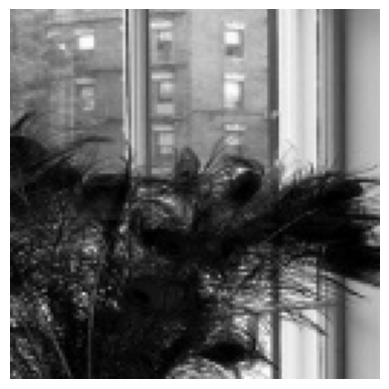

In [ ]:
import matplotlib.pyplot as plt

sample = cv2.imread(
    os.path.join(DATA_ROOT, 'split/Train_synthetic/PA/1a.jpg'),
    cv2.IMREAD_GRAYSCALE
)

plt.imshow(sample, cmap='gray')
plt.axis('off')
plt.show()

CNN Supervised

In [ ]:
if IN_COLAB:
    !pip install torch torchvision tensorboard tqdm opencv-python pytorch-lightning
else:
    print('Local packages already verified')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.6 MB/s eta 0:00:00


In [ ]:
rm -rf '/content/checkpoints'

In [ ]:
if IN_COLAB:
    # Standard supervised train in Google Colab
    !python /content/Code/PhamHungSon_15_CNN_Train_Sup.py \
      --BasePath=/content/data/synthetic \
      --CheckPointPath=/content/checkpoints/ \
      --LogsPath=/content/logs/ \
      --NumEpochs=25 \
      --MiniBatchSize=64 \
      --DivTrain=1 \
      --LoadCheckPoint=0 \
      --Optimizer=Adam \
      --LR=0.001 \
      --Backbone=ConvNet
else:
    # Run local train with upgraded Adam optimizer and stable parameters
    # You can set --Backbone=ResNet18 to run the state-of-the-art ResNet-18 model!
    !python {CODE_ROOT}/PhamHungSon_15_CNN_Train_Sup.py \
      --NumEpochs=5 \
      --MiniBatchSize=64 \
      --DivTrain=1 \
      --LoadCheckPoint=0 \
      --Optimizer=Adam \
      --LR=0.0005 \
      --Backbone=ConvNet


Streaming output truncated to the last 5000 lines.
Validation Loss: 19.238489151000977

[ITER 106/200]
[BATCH-Train] matched=8/8 batch=8
Input shape: torch.Size([8, 2, 128, 128])
Label shape: torch.Size([8, 8])
Prediction shape: torch.Size([8, 8])
Train Loss: 18.839353561401367
Learning Rate: 5e-05
[BATCH-Validation] matched=8/8 batch=8
Validation Loss: 18.440683364868164

[ITER 107/200]
[BATCH-Train] matched=8/8 batch=8
Input shape: torch.Size([8, 2, 128, 128])
Label shape: torch.Size([8, 8])
Prediction shape: torch.Size([8, 8])
Train Loss: 18.14650535583496
Learning Rate: 5e-05
[BATCH-Validation] matched=8/8 batch=8
Validation Loss: 19.442378997802734

[ITER 108/200]
[BATCH-Train] matched=8/8 batch=8
Input shape: torch.Size([8, 2, 128, 128])
Label shape: torch.Size([8, 8])
Prediction shape: torch.Size([8, 8])
Train Loss: 20.955005645751953
Learning Rate: 5e-05
[BATCH-Validation] matched=8/8 batch=8
Validation Loss: 19.51816177368164

[ITER 109/200]
[BATCH-Train] matched=8/8 batch=8
I

Test

In [ ]:
if IN_COLAB:
    !python /content/Code/PhamHungSon_15_CNN_Test_Sup.py \
      --ModelPath='/content/checkpoints/0model.ckpt' \
      --BasePath=/content/data/synthetic/Test_synthetic/ \
      --LabelsPath='/content/data/synthetic/Test_synthetic/H4.csv' \
      --Backbone=ConvNet
else:
    # Run local test. Set --Backbone=ResNet18 if you trained the ResNet-18 model!
    !python {CODE_ROOT}/PhamHungSon_15_CNN_Test_Sup.py \
      --Backbone=ConvNet


/content/Code/PhamHungSon_15_CNN_Test_Sup.py:215: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Patched_batch.append(torch.tensor(stacked_image))
Number of parameters in this model are 60 
100% 400/400 [00:15<00:00, 25.45it/s]

Saving visualization images to: /content/results/Supervised_test
[0] Saved -> /content/results/Supervised_test/Image0.png
[1] Saved -> /content/results/Supervised_test/Image1.png
[2] Saved -> /content/results/Supervised_test/Image2.png
[3] Saved -> /content/results/Supervised_test/Image3.png
[4] Saved -> /content/results/Supervised_test/Image4.png
[5] Saved -> /content/results/Supervised_test/Image5.png
[6] Saved -> /content/results/Supervised_test/Image6.png
[7] Saved -> /content/results/Supervised_test/Image7.png
[8] Saved -> /content/results/Supervised_test/Image8.png
[9] Saved -> /content/results/Supervised_t

Stiching Images

In [ ]:
if IN_COLAB:
    !python /content/Code/PhamHungSon_15_CNN_Wrapper_Sup.py
else:
    # Run local wrapper
    !python {CODE_ROOT}/PhamHungSon_15_CNN_Wrapper_Sup.py


/content/Code/PhamHungSon_15_CNN_Wrapper_Sup.py:55: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  I1Batch.append(torch.tensor(stacked_image))
Showing step 1 merge output:
<PIL.Image.Image image mode=RGB size=3287x4196 at 0x7FDF71DDD820>
Step panorama saved at: /content/panorama/results/Step_1_Stitched_20260524030018.png
Showing step 2 merge output:
<PIL.Image.Image image mode=RGB size=3703x4585 at 0x7FDF71D7A150>
Step panorama saved at: /content/panorama/results/Step_2_Stitched_20260524030020.png
Showing step 3 merge output:
<PIL.Image.Image image mode=RGB size=4697x5512 at 0x7FDF71D7A150>
Step panorama saved at: /content/panorama/results/Step_3_Stitched_20260524030022.png
Showing step 4 merge output:
<PIL.Image.Image image mode=RGB size=7851x8465 at 0x7FDF71D7A150>
Step panorama saved at: /content/panorama/results/Step_4_Stitched_20260